In [ ]:
import pandas as pd
df=pd.read_csv('Wine.csv')
df.head()


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Customer_Segment
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1


In [ ]:
df.shape

(178, 14)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:

from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [ ]:
df = pd.read_csv("Wine.csv")

print("Shape:", df.shape)
print(df.head())

X = df.drop("Customer_Segment", axis=1)
y = df["Customer_Segment"]


Shape: (178, 14)
   Alcohol  Malic_Acid   Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
0    14.23        1.71  2.43          15.6        127           2.80   
1    13.20        1.78  2.14          11.2        100           2.65   
2    13.16        2.36  2.67          18.6        101           2.80   
3    14.37        1.95  2.50          16.8        113           3.85   
4    13.24        2.59  2.87          21.0        118           2.80   

   Flavanoids  Nonflavanoid_Phenols  Proanthocyanins  Color_Intensity   Hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   OD280  Proline  Customer_Segment  
0   3.92     1065                 1  

In [ ]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

print("\nExplained Variance Ratio:", lda.explained_variance_ratio_)



Explained Variance Ratio: [0.68747889 0.31252111]


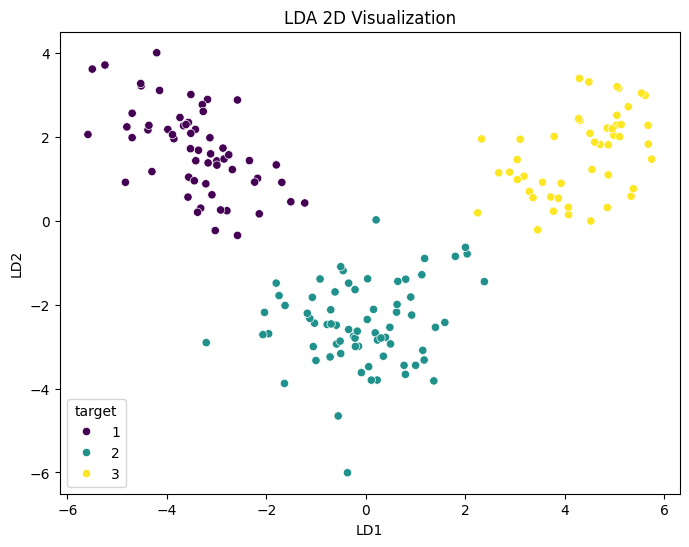

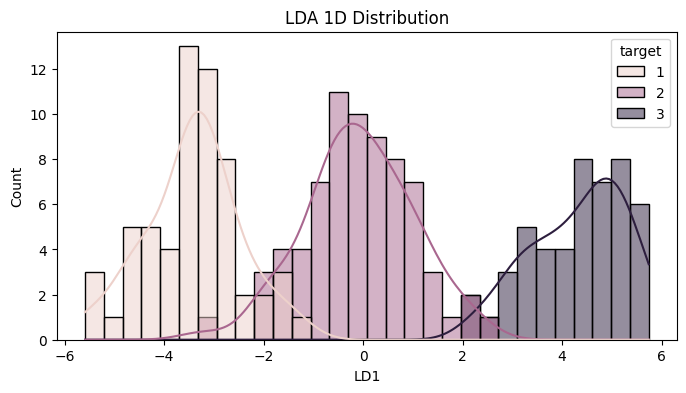

In [ ]:

lda_df = pd.DataFrame(data=X_lda, columns=["LD1", "LD2"])
lda_df["target"] = y

plt.figure(figsize=(8,6))
sns.scatterplot(x="LD1", y="LD2", hue="target", data=lda_df, palette="viridis")
plt.title("LDA 2D Visualization")
plt.show()

plt.figure(figsize=(8,4))
sns.histplot(data=lda_df, x="LD1", hue="target", bins=30, kde=True)
plt.title("LDA 1D Distribution")
plt.show()


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

lda_clf = LDA()
lda_clf.fit(X_train, y_train)

y_pred = lda_clf.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")


Accuracy: 1.0

Classification Report:



              precision    recall  f1-score   support

           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        14
           3       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



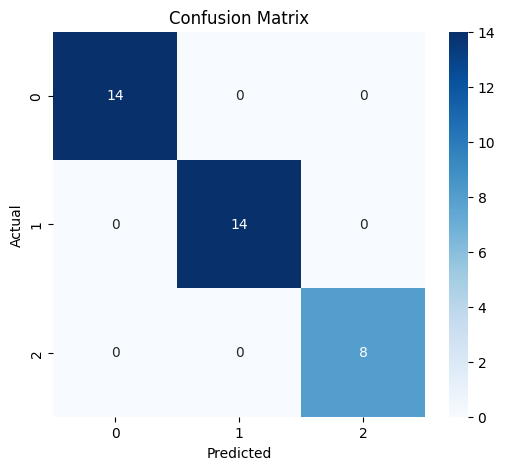

In [ ]:

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import kagglehub

path = kagglehub.dataset_download("benhamner/nips-papers")

print("Path to dataset files:", path)

100%|██████████| 141M/141M [00:07<00:00, 20.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/benhamner/nips-papers/versions/2


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:

from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:

!pip install gensim
import pandas as pd
import nltk
from gensim import corpora
import gensim
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

data = pd.read_csv("/root/.cache/kagglehub/datasets/benhamner/nips-papers/versions/2/papers.csv")

stop = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    tokens = nltk.word_tokenize(text)
    tokens = [w for w in tokens if w.isalpha() and w not in stop and len(w) > 3]
    tokens = [lemmatizer.lemmatize(w, pos='v') for w in tokens]
    return tokens

data["processed"] = data["paper_text"].apply(preprocess)

dictionary = corpora.Dictionary(data["processed"])
corpus = [dictionary.doc2bow(text) for text in data["processed"]]

lda_model = gensim.models.ldamodel.LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=4,
    random_state=100,
    passes=10
)

topics = lda_model.print_topics()
for topic in topics:
    print(topic)

from gensim.models import CoherenceModel

coherence_model = CoherenceModel(
    model=lda_model,
    texts=data["processed"],
    dictionary=dictionary,
    coherence='c_v'
)

print("Coherence Score:", coherence_model.get_coherence())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 49.4 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


(0, '0.012*"algorithm" + 0.010*"function" + 0.007*"learn" + 0.007*"problem" + 0.007*"result" + 0.006*"matrix" + 0.006*"use" + 0.005*"theorem" + 0.005*"follow" + 0.005*"show"')
(1, '0.013*"model" + 0.009*"image" + 0.007*"figure" + 0.007*"use" + 0.006*"time" + 0.006*"show" + 0.006*"input" + 0.006*"neural" + 0.005*"network" + 0.005*"signal"')
(2, '0.022*"model" + 0.010*"use" + 0.009*"data" + 0.008*"learn" + 0.008*"sample" + 0.007*"distribution" + 0.007*"function" + 0.007*"state" + 0.006*"process" + 0.005*"time"')
(3, '0.019*"network" + 0.018*"learn" + 0.016*"train" + 0.011*"use" + 0.011*"model" + 0.009*"image" + 0.008*"neural" + 0.008*"feature" + 0.007*"layer" + 0.006*"input"')
Coherence Score: 0.3445870338256883


2 Coherence_Measure(seg=<function s_one_set at 0x7ca365223100>, prob=<function p_boolean_sliding_window at 0x7ca365223380>, conf=<function cosine_similarity at 0x7ca36515ce00>, aggr=<function arithmetic_mean at 0x7ca365222f20>)


3 Coherence_Measure(seg=<function s_one_set at 0x7ca365223100>, prob=<function p_boolean_sliding_window at 0x7ca365223380>, conf=<function cosine_similarity at 0x7ca36515ce00>, aggr=<function arithmetic_mean at 0x7ca365222f20>)


4 Coherence_Measure(seg=<function s_one_set at 0x7ca365223100>, prob=<function p_boolean_sliding_window at 0x7ca365223380>, conf=<function cosine_similarity at 0x7ca36515ce00>, aggr=<function arithmetic_mean at 0x7ca365222f20>)


5 Coherence_Measure(seg=<function s_one_set at 0x7ca365223100>, prob=<function p_boolean_sliding_window at 0x7ca365223380>, conf=<function cosine_similarity at 0x7ca36515ce00>, aggr=<function arithmetic_mean at 0x7ca365222f20>)


6 Coherence_Measure(seg=<function s_one_set at 0x7ca365223100>, prob=<function p_boolean_sliding_window at 0x7ca365223380>, conf=<function cosine_similarity at 0x7ca36515ce00>, aggr=<function arithmetic_mean at 0x7ca365222f20>)


7 Coherence_Measure(seg=<function s_one_set at 0x7ca365223100>, prob=<function p_boolean_sliding_window at 0x7ca365223380>, conf=<function cosine_similarity at 0x7ca36515ce00>, aggr=<function arithmetic_mean at 0x7ca365222f20>)


8 Coherence_Measure(seg=<function s_one_set at 0x7ca365223100>, prob=<function p_boolean_sliding_window at 0x7ca365223380>, conf=<function cosine_similarity at 0x7ca36515ce00>, aggr=<function arithmetic_mean at 0x7ca365222f20>)


9 Coherence_Measure(seg=<function s_one_set at 0x7ca365223100>, prob=<function p_boolean_sliding_window at 0x7ca365223380>, conf=<function cosine_similarity at 0x7ca36515ce00>, aggr=<function arithmetic_mean at 0x7ca365222f20>)


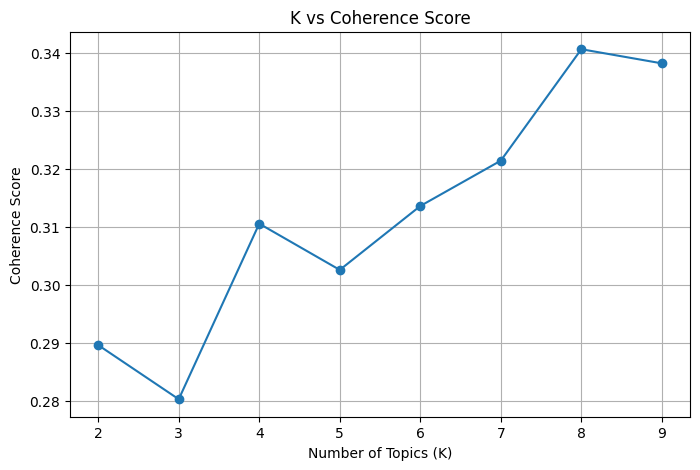

In [ ]:
import matplotlib.pyplot as plt
from gensim.models import CoherenceModel
import gensim

coherence_scores = []
k_values = range(2, 10)

for k in k_values:
    lda = gensim.models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        passes=2,
        random_state=100
    )

    coherence_model = CoherenceModel(
        model=lda,
        texts=data["processed"],
        dictionary=dictionary,
        coherence='c_v'
    )
    print(k, coherence_model)
    coherence_scores.append(coherence_model.get_coherence())

plt.figure(figsize=(8,5))
plt.plot(k_values, coherence_scores, marker='o')
plt.xlabel("Number of Topics (K)")
plt.ylabel("Coherence Score")
plt.title("K vs Coherence Score")
plt.grid()
plt.show()

In [ ]:
import sys
!{sys.executable} -m pip install gensim

import pandas as pd
import nltk
from gensim import corpora
import gensim
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

data = pd.read_csv("/root/.cache/kagglehub/datasets/benhamner/nips-papers/versions/2/papers.csv")

stop = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    tokens = nltk.word_tokenize(text)
    tokens = [w for w in tokens if w.isalpha() and w not in stop and len(w) > 3]
    tokens = [lemmatizer.lemmatize(w, pos='v') for w in tokens]
    return tokens

data["processed"] = data["paper_text"].apply(preprocess)

from gensim.models import Phrases

bigram = Phrases(data["processed"], min_count=5, threshold=10)
bigram_mod = gensim.models.phrases.Phraser(bigram)

data["processed"] = data["processed"].apply(lambda x: bigram_mod[x])

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


FileNotFoundError: [Errno 2] No such file or directory: '/root/.cache/kagglehub/datasets/benhamner/nips-papers/versions/2/papers.csv/papers.csv'

In [ ]:
import kagglehub

path = kagglehub.dataset_download("benhamner/nips-papers")

print("Path to dataset files:", path)

100%|██████████| 141M/141M [00:07<00:00, 20.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/benhamner/nips-papers/versions/2


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:

from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:

!pip install gensim
import pandas as pd
import nltk
from gensim import corpora
import gensim
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

data = pd.read_csv("/root/.cache/kagglehub/datasets/benhamner/nips-papers/versions/2/papers.csv")

stop = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    tokens = nltk.word_tokenize(text)
    tokens = [w for w in tokens if w.isalpha() and w not in stop and len(w) > 3]
    tokens = [lemmatizer.lemmatize(w, pos='v') for w in tokens]
    return tokens

data["processed"] = data["paper_text"].apply(preprocess)

dictionary = corpora.Dictionary(data["processed"])
corpus = [dictionary.doc2bow(text) for text in data["processed"]]

lda_model = gensim.models.ldamodel.LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=4,
    random_state=100,
    passes=10
)

topics = lda_model.print_topics()
for topic in topics:
    print(topic)

from gensim.models import CoherenceModel

coherence_model = CoherenceModel(
    model=lda_model,
    texts=data["processed"],
    dictionary=dictionary,
    coherence='c_v'
)

print("Coherence Score:", coherence_model.get_coherence())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 49.4 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


(0, '0.012*"algorithm" + 0.010*"function" + 0.007*"learn" + 0.007*"problem" + 0.007*"result" + 0.006*"matrix" + 0.006*"use" + 0.005*"theorem" + 0.005*"follow" + 0.005*"show"')
(1, '0.013*"model" + 0.009*"image" + 0.007*"figure" + 0.007*"use" + 0.006*"time" + 0.006*"show" + 0.006*"input" + 0.006*"neural" + 0.005*"network" + 0.005*"signal"')
(2, '0.022*"model" + 0.010*"use" + 0.009*"data" + 0.008*"learn" + 0.008*"sample" + 0.007*"distribution" + 0.007*"function" + 0.007*"state" + 0.006*"process" + 0.005*"time"')
(3, '0.019*"network" + 0.018*"learn" + 0.016*"train" + 0.011*"use" + 0.011*"model" + 0.009*"image" + 0.008*"neural" + 0.008*"feature" + 0.007*"layer" + 0.006*"input"')
Coherence Score: 0.3445870338256883


2 Coherence_Measure(seg=<function s_one_set at 0x7ca365223100>, prob=<function p_boolean_sliding_window at 0x7ca365223380>, conf=<function cosine_similarity at 0x7ca36515ce00>, aggr=<function arithmetic_mean at 0x7ca365222f20>)


3 Coherence_Measure(seg=<function s_one_set at 0x7ca365223100>, prob=<function p_boolean_sliding_window at 0x7ca365223380>, conf=<function cosine_similarity at 0x7ca36515ce00>, aggr=<function arithmetic_mean at 0x7ca365222f20>)


4 Coherence_Measure(seg=<function s_one_set at 0x7ca365223100>, prob=<function p_boolean_sliding_window at 0x7ca365223380>, conf=<function cosine_similarity at 0x7ca36515ce00>, aggr=<function arithmetic_mean at 0x7ca365222f20>)


5 Coherence_Measure(seg=<function s_one_set at 0x7ca365223100>, prob=<function p_boolean_sliding_window at 0x7ca365223380>, conf=<function cosine_similarity at 0x7ca36515ce00>, aggr=<function arithmetic_mean at 0x7ca365222f20>)


6 Coherence_Measure(seg=<function s_one_set at 0x7ca365223100>, prob=<function p_boolean_sliding_window at 0x7ca365223380>, conf=<function cosine_similarity at 0x7ca36515ce00>, aggr=<function arithmetic_mean at 0x7ca365222f20>)


7 Coherence_Measure(seg=<function s_one_set at 0x7ca365223100>, prob=<function p_boolean_sliding_window at 0x7ca365223380>, conf=<function cosine_similarity at 0x7ca36515ce00>, aggr=<function arithmetic_mean at 0x7ca365222f20>)


8 Coherence_Measure(seg=<function s_one_set at 0x7ca365223100>, prob=<function p_boolean_sliding_window at 0x7ca365223380>, conf=<function cosine_similarity at 0x7ca36515ce00>, aggr=<function arithmetic_mean at 0x7ca365222f20>)


9 Coherence_Measure(seg=<function s_one_set at 0x7ca365223100>, prob=<function p_boolean_sliding_window at 0x7ca365223380>, conf=<function cosine_similarity at 0x7ca36515ce00>, aggr=<function arithmetic_mean at 0x7ca365222f20>)


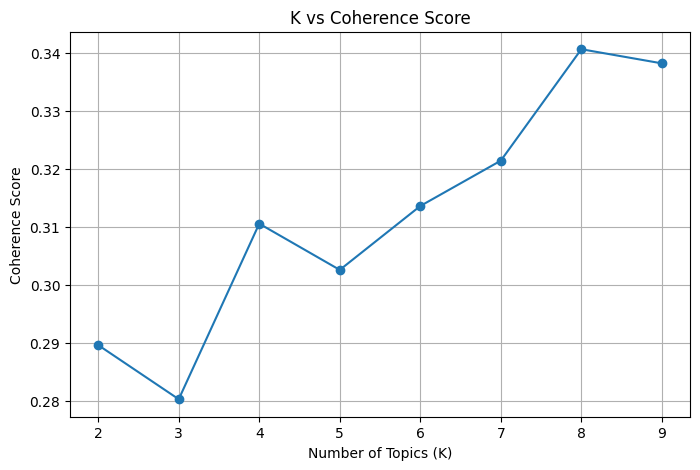

In [ ]:
import matplotlib.pyplot as plt
from gensim.models import CoherenceModel
import gensim

coherence_scores = []
k_values = range(2, 10)

for k in k_values:
    lda = gensim.models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        passes=2,
        random_state=100
    )

    coherence_model = CoherenceModel(
        model=lda,
        texts=data["processed"],
        dictionary=dictionary,
        coherence='c_v'
    )
    print(k, coherence_model)
    coherence_scores.append(coherence_model.get_coherence())

plt.figure(figsize=(8,5))
plt.plot(k_values, coherence_scores, marker='o')
plt.xlabel("Number of Topics (K)")
plt.ylabel("Coherence Score")
plt.title("K vs Coherence Score")
plt.grid()
plt.show()

In [ ]:
import sys
!{sys.executable} -m pip install gensim

import pandas as pd
import nltk
from gensim import corpora
import gensim
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import os

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

dataset_path = '/root/.cache/kagglehub/datasets/benhamner/nips-papers/versions/2/papers.csv'
data = pd.read_csv(os.path.join(dataset_path, 'papers.csv'))

stop = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    tokens = nltk.word_tokenize(text)
    tokens = [w for w in tokens if w.isalpha() and w not in stop and len(w) > 3]
    tokens = [lemmatizer.lemmatize(w, pos='v') for w in tokens]
    return tokens

data["processed"] = data["paper_text"].apply(preprocess)

from gensim.models import Phrases

bigram = Phrases(data["processed"], min_count=5, threshold=10)
bigram_mod = gensim.models.phrases.Phraser(bigram)

data["processed"] = data["processed"].apply(lambda x: bigram_mod[x])

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


FileNotFoundError: [Errno 2] No such file or directory: '/root/.cache/kagglehub/datasets/benhamner/nips-papers/versions/2/papers.csv/papers.csv'

In [ ]:
import kagglehub

path = kagglehub.dataset_download("benhamner/nips-papers")

print("Path to dataset files:", path)

100%|██████████| 141M/141M [00:07<00:00, 20.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/benhamner/nips-papers/versions/2


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:

from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:

!pip install gensim
import pandas as pd
import nltk
from gensim import corpora
import gensim
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

data = pd.read_csv("/root/.cache/kagglehub/datasets/benhamner/nips-papers/versions/2/papers.csv")

stop = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    tokens = nltk.word_tokenize(text)
    tokens = [w for w in tokens if w.isalpha() and w not in stop and len(w) > 3]
    tokens = [lemmatizer.lemmatize(w, pos='v') for w in tokens]
    return tokens

data["processed"] = data["paper_text"].apply(preprocess)

dictionary = corpora.Dictionary(data["processed"])
corpus = [dictionary.doc2bow(text) for text in data["processed"]]

lda_model = gensim.models.ldamodel.LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=4,
    random_state=100,
    passes=10
)

topics = lda_model.print_topics()
for topic in topics:
    print(topic)

from gensim.models import CoherenceModel

coherence_model = CoherenceModel(
    model=lda_model,
    texts=data["processed"],
    dictionary=dictionary,
    coherence='c_v'
)

print("Coherence Score:", coherence_model.get_coherence())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 49.4 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


(0, '0.012*"algorithm" + 0.010*"function" + 0.007*"learn" + 0.007*"problem" + 0.007*"result" + 0.006*"matrix" + 0.006*"use" + 0.005*"theorem" + 0.005*"follow" + 0.005*"show"')
(1, '0.013*"model" + 0.009*"image" + 0.007*"figure" + 0.007*"use" + 0.006*"time" + 0.006*"show" + 0.006*"input" + 0.006*"neural" + 0.005*"network" + 0.005*"signal"')
(2, '0.022*"model" + 0.010*"use" + 0.009*"data" + 0.008*"learn" + 0.008*"sample" + 0.007*"distribution" + 0.007*"function" + 0.007*"state" + 0.006*"process" + 0.005*"time"')
(3, '0.019*"network" + 0.018*"learn" + 0.016*"train" + 0.011*"use" + 0.011*"model" + 0.009*"image" + 0.008*"neural" + 0.008*"feature" + 0.007*"layer" + 0.006*"input"')
Coherence Score: 0.3445870338256883


2 Coherence_Measure(seg=<function s_one_set at 0x7ca365223100>, prob=<function p_boolean_sliding_window at 0x7ca365223380>, conf=<function cosine_similarity at 0x7ca36515ce00>, aggr=<function arithmetic_mean at 0x7ca365222f20>)


3 Coherence_Measure(seg=<function s_one_set at 0x7ca365223100>, prob=<function p_boolean_sliding_window at 0x7ca365223380>, conf=<function cosine_similarity at 0x7ca36515ce00>, aggr=<function arithmetic_mean at 0x7ca365222f20>)


4 Coherence_Measure(seg=<function s_one_set at 0x7ca365223100>, prob=<function p_boolean_sliding_window at 0x7ca365223380>, conf=<function cosine_similarity at 0x7ca36515ce00>, aggr=<function arithmetic_mean at 0x7ca365222f20>)


5 Coherence_Measure(seg=<function s_one_set at 0x7ca365223100>, prob=<function p_boolean_sliding_window at 0x7ca365223380>, conf=<function cosine_similarity at 0x7ca36515ce00>, aggr=<function arithmetic_mean at 0x7ca365222f20>)


6 Coherence_Measure(seg=<function s_one_set at 0x7ca365223100>, prob=<function p_boolean_sliding_window at 0x7ca365223380>, conf=<function cosine_similarity at 0x7ca36515ce00>, aggr=<function arithmetic_mean at 0x7ca365222f20>)


7 Coherence_Measure(seg=<function s_one_set at 0x7ca365223100>, prob=<function p_boolean_sliding_window at 0x7ca365223380>, conf=<function cosine_similarity at 0x7ca36515ce00>, aggr=<function arithmetic_mean at 0x7ca365222f20>)


8 Coherence_Measure(seg=<function s_one_set at 0x7ca365223100>, prob=<function p_boolean_sliding_window at 0x7ca365223380>, conf=<function cosine_similarity at 0x7ca36515ce00>, aggr=<function arithmetic_mean at 0x7ca365222f20>)


9 Coherence_Measure(seg=<function s_one_set at 0x7ca365223100>, prob=<function p_boolean_sliding_window at 0x7ca365223380>, conf=<function cosine_similarity at 0x7ca36515ce00>, aggr=<function arithmetic_mean at 0x7ca365222f20>)


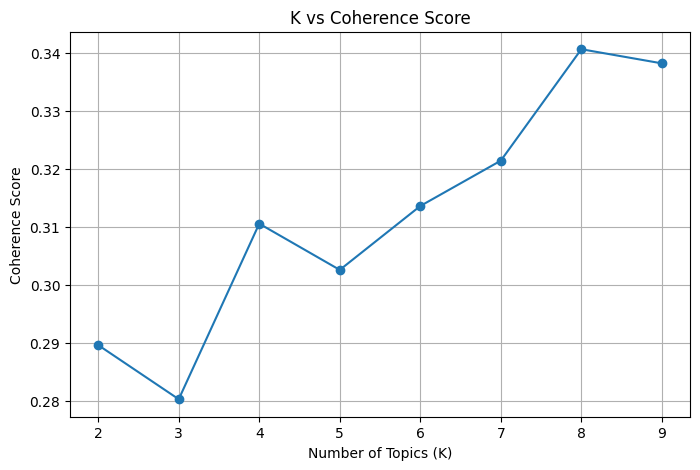

In [ ]:
import matplotlib.pyplot as plt
from gensim.models import CoherenceModel
import gensim

coherence_scores = []
k_values = range(2, 10)

for k in k_values:
    lda = gensim.models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        passes=2,
        random_state=100
    )

    coherence_model = CoherenceModel(
        model=lda,
        texts=data["processed"],
        dictionary=dictionary,
        coherence='c_v'
    )
    print(k, coherence_model)
    coherence_scores.append(coherence_model.get_coherence())

plt.figure(figsize=(8,5))
plt.plot(k_values, coherence_scores, marker='o')
plt.xlabel("Number of Topics (K)")
plt.ylabel("Coherence Score")
plt.title("K vs Coherence Score")
plt.grid()
plt.show()

In [ ]:
import sys
!{sys.executable} -m pip install gensim

import pandas as pd
import nltk
from gensim import corpora
import gensim
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import os

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

dataset_path = '/root/.cache/kagglehub/datasets/benhamner/nips-papers/versions/2/papers.csv'
data = pd.read_csv(os.path.join(dataset_path, 'papers.csv'))

stop = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    tokens = nltk.word_tokenize(text)
    tokens = [w for w in tokens if w.isalpha() and w not in stop and len(w) > 3]
    tokens = [lemmatizer.lemmatize(w, pos='v') for w in tokens]
    return tokens

data["processed"] = data["paper_text"].apply(preprocess)

from gensim.models import Phrases

bigram = Phrases(data["processed"], min_count=5, threshold=10)
bigram_mod = gensim.models.phrases.Phraser(bigram)

data["processed"] = data["processed"].apply(lambda x: bigram_mod[x])

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


FileNotFoundError: [Errno 2] No such file or directory: '/root/.cache/kagglehub/datasets/benhamner/nips-papers/versions/2/papers.csv/papers.csv'

In [ ]:
import kagglehub

path = kagglehub.dataset_download("benhamner/nips-papers")

print("Path to dataset files:", path)

100%|██████████| 141M/141M [00:07<00:00, 20.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/benhamner/nips-papers/versions/2


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:

from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:

!pip install gensim
import pandas as pd
import nltk
from gensim import corpora
import gensim
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

data = pd.read_csv("/root/.cache/kagglehub/datasets/benhamner/nips-papers/versions/2/papers.csv")

stop = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    tokens = nltk.word_tokenize(text)
    tokens = [w for w in tokens if w.isalpha() and w not in stop and len(w) > 3]
    tokens = [lemmatizer.lemmatize(w, pos='v') for w in tokens]
    return tokens

data["processed"] = data["paper_text"].apply(preprocess)

dictionary = corpora.Dictionary(data["processed"])
corpus = [dictionary.doc2bow(text) for text in data["processed"]]

lda_model = gensim.models.ldamodel.LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=4,
    random_state=100,
    passes=10
)

topics = lda_model.print_topics()
for topic in topics:
    print(topic)

from gensim.models import CoherenceModel

coherence_model = CoherenceModel(
    model=lda_model,
    texts=data["processed"],
    dictionary=dictionary,
    coherence='c_v'
)

print("Coherence Score:", coherence_model.get_coherence())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 49.4 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


(0, '0.012*"algorithm" + 0.010*"function" + 0.007*"learn" + 0.007*"problem" + 0.007*"result" + 0.006*"matrix" + 0.006*"use" + 0.005*"theorem" + 0.005*"follow" + 0.005*"show"')
(1, '0.013*"model" + 0.009*"image" + 0.007*"figure" + 0.007*"use" + 0.006*"time" + 0.006*"show" + 0.006*"input" + 0.006*"neural" + 0.005*"network" + 0.005*"signal"')
(2, '0.022*"model" + 0.010*"use" + 0.009*"data" + 0.008*"learn" + 0.008*"sample" + 0.007*"distribution" + 0.007*"function" + 0.007*"state" + 0.006*"process" + 0.005*"time"')
(3, '0.019*"network" + 0.018*"learn" + 0.016*"train" + 0.011*"use" + 0.011*"model" + 0.009*"image" + 0.008*"neural" + 0.008*"feature" + 0.007*"layer" + 0.006*"input"')
Coherence Score: 0.3445870338256883


2 Coherence_Measure(seg=<function s_one_set at 0x7ca365223100>, prob=<function p_boolean_sliding_window at 0x7ca365223380>, conf=<function cosine_similarity at 0x7ca36515ce00>, aggr=<function arithmetic_mean at 0x7ca365222f20>)


3 Coherence_Measure(seg=<function s_one_set at 0x7ca365223100>, prob=<function p_boolean_sliding_window at 0x7ca365223380>, conf=<function cosine_similarity at 0x7ca36515ce00>, aggr=<function arithmetic_mean at 0x7ca365222f20>)


4 Coherence_Measure(seg=<function s_one_set at 0x7ca365223100>, prob=<function p_boolean_sliding_window at 0x7ca365223380>, conf=<function cosine_similarity at 0x7ca36515ce00>, aggr=<function arithmetic_mean at 0x7ca365222f20>)


5 Coherence_Measure(seg=<function s_one_set at 0x7ca365223100>, prob=<function p_boolean_sliding_window at 0x7ca365223380>, conf=<function cosine_similarity at 0x7ca36515ce00>, aggr=<function arithmetic_mean at 0x7ca365222f20>)


6 Coherence_Measure(seg=<function s_one_set at 0x7ca365223100>, prob=<function p_boolean_sliding_window at 0x7ca365223380>, conf=<function cosine_similarity at 0x7ca36515ce00>, aggr=<function arithmetic_mean at 0x7ca365222f20>)


7 Coherence_Measure(seg=<function s_one_set at 0x7ca365223100>, prob=<function p_boolean_sliding_window at 0x7ca365223380>, conf=<function cosine_similarity at 0x7ca36515ce00>, aggr=<function arithmetic_mean at 0x7ca365222f20>)


8 Coherence_Measure(seg=<function s_one_set at 0x7ca365223100>, prob=<function p_boolean_sliding_window at 0x7ca365223380>, conf=<function cosine_similarity at 0x7ca36515ce00>, aggr=<function arithmetic_mean at 0x7ca365222f20>)


9 Coherence_Measure(seg=<function s_one_set at 0x7ca365223100>, prob=<function p_boolean_sliding_window at 0x7ca365223380>, conf=<function cosine_similarity at 0x7ca36515ce00>, aggr=<function arithmetic_mean at 0x7ca365222f20>)


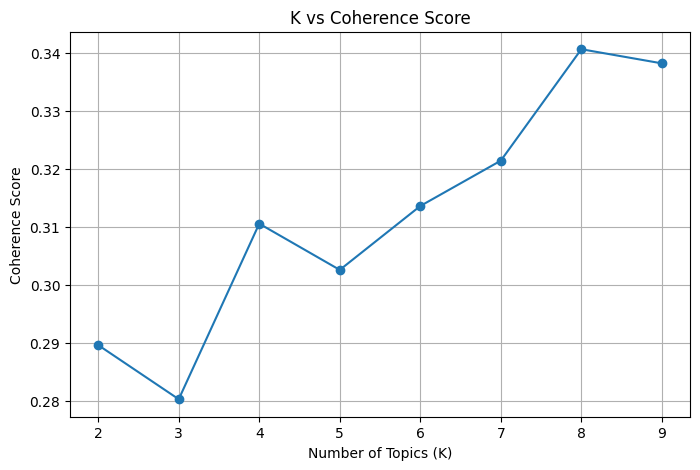

In [ ]:
import matplotlib.pyplot as plt
from gensim.models import CoherenceModel
import gensim

coherence_scores = []
k_values = range(2, 10)

for k in k_values:
    lda = gensim.models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        passes=2,
        random_state=100
    )

    coherence_model = CoherenceModel(
        model=lda,
        texts=data["processed"],
        dictionary=dictionary,
        coherence='c_v'
    )
    print(k, coherence_model)
    coherence_scores.append(coherence_model.get_coherence())

plt.figure(figsize=(8,5))
plt.plot(k_values, coherence_scores, marker='o')
plt.xlabel("Number of Topics (K)")
plt.ylabel("Coherence Score")
plt.title("K vs Coherence Score")
plt.grid()
plt.show()

In [ ]:
import sys
!{sys.executable} -m pip install gensim

import pandas as pd
import nltk
from gensim import corpora
import gensim
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import os
import kagglehub # Added kagglehub import

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

# Dynamically get the dataset path
dataset_root_path = kagglehub.dataset_download("benhamner/nips-papers")
# The 'path' returned by kagglehub.dataset_download is a Path object, convert to string
dataset_root_path = str(dataset_root_path)

# Assuming 'papers.csv' is directly in the downloaded root directory.
# If it's in a subfolder like 'nips-papers', we would adjust data_file_path accordingly.
data_file_path = os.path.join(dataset_root_path, 'papers.csv')

# Print contents of the directory for debugging purposes
print(f"Contents of dataset root directory ({dataset_root_path}): {os.listdir(dataset_root_path)}")
print(f"Attempting to read CSV from: {data_file_path}")

data = pd.read_csv(data_file_path)

stop = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    tokens = nltk.word_tokenize(text)
    tokens = [w for w in tokens if w.isalpha() and w not in stop and len(w) > 3]
    tokens = [lemmatizer.lemmatize(w, pos='v') for w in tokens]
    return tokens

data["processed"] = data["paper_text"].apply(preprocess)

from gensim.models import Phrases

bigram = Phrases(data["processed"], min_count=5, threshold=10)
bigram_mod = gensim.models.phrases.Phraser(bigram)

data["processed"] = data["processed"].apply(lambda x: bigram_mod[x])

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


100%|██████████| 141M/141M [00:01<00:00, 140MB/s]

Extracting files...


Contents of dataset root directory (/root/.cache/kagglehub/datasets/benhamner/nips-papers/versions/2): ['database.sqlite', 'papers.csv', 'paper_authors.csv', 'authors.csv']
Attempting to read CSV from: /root/.cache/kagglehub/datasets/benhamner/nips-papers/versions/2/papers.csv


In [ ]:
import sys
!{sys.executable} -m pip install gensim

import pandas as pd
import nltk
from gensim import corpora
import gensim # Added for Phrases and Phraser
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import os
import kagglehub

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

# Dynamically get the dataset path
dataset_root_path = kagglehub.dataset_download("benhamner/nips-papers")
# The 'path' returned by kagglehub.dataset_download is a Path object, convert to string
dataset_root_path = str(dataset_root_path)

# Assuming 'papers.csv' is directly in the downloaded root directory.
data_file_path = os.path.join(dataset_root_path, 'papers.csv')

data = pd.read_csv(data_file_path)

stop = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    tokens = nltk.word_tokenize(text)
    tokens = [w for w in tokens if w.isalpha() and w not in stop and len(w) > 3]
    tokens = [lemmatizer.lemmatize(w, pos='v') for w in tokens]
    return tokens

data["processed"] = data["paper_text"].apply(preprocess)

# Apply bigram processing
from gensim.models import Phrases
bigram = Phrases(data["processed"], min_count=5, threshold=10)
bigram_mod = gensim.models.phrases.Phraser(bigram)
data["processed"] = data["processed"].apply(lambda x: bigram_mod[x])

dictionary = corpora.Dictionary(data["processed"])

dictionary.filter_extremes(no_below=20, no_above=0.4)

corpus = [dictionary.doc2bow(text) for text in data["processed"]]

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Using Colab cache for faster access to the 'nips-papers' dataset.


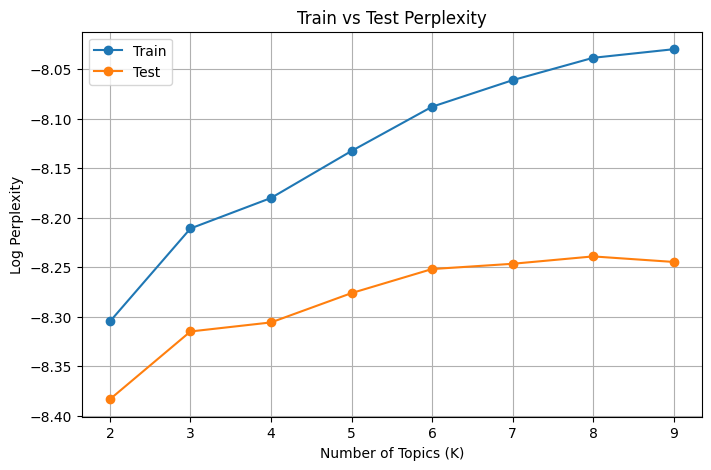

In [ ]:
from sklearn.model_selection import train_test_split

train_corpus, test_corpus = train_test_split(corpus, test_size=0.2, random_state=42)

train_scores = []
test_scores = []

k_values = range(2, 10)

for k in k_values:
    lda = gensim.models.LdaModel(
        corpus=train_corpus,
        id2word=dictionary,
        num_topics=k,
        passes=10,
        random_state=100
    )

    train_scores.append(lda.log_perplexity(train_corpus))
    test_scores.append(lda.log_perplexity(test_corpus))

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(k_values, train_scores, marker='o', label='Train')
plt.plot(k_values, test_scores, marker='o', label='Test')
plt.xlabel("Number of Topics (K)")
plt.ylabel("Log Perplexity")
plt.title("Train vs Test Perplexity")
plt.legend()
plt.grid()
plt.show()

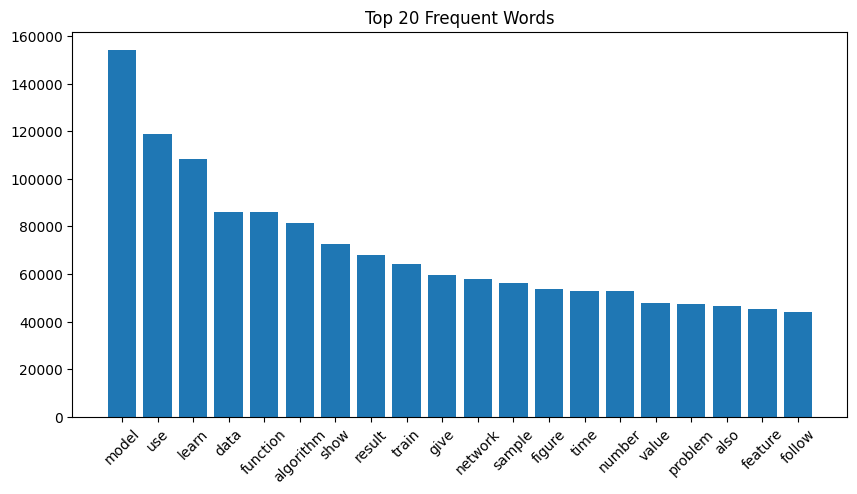

In [ ]:
from collections import Counter

all_words = [word for text in data["processed"] for word in text]
counter = Counter(all_words)

common_words = counter.most_common(20)

words = [w for w, _ in common_words]
counts = [c for _, c in common_words]

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Frequent Words")
plt.show()